# 03 — Dynamic Pricing & Revenue Optimization Engine
### Dynamic Pricing & Revenue Intelligence System | Final Year B.Tech Project
---
**Objective:** Deliver an end-to-end pricing decision engine combining empirical price elasticity, competitor-aware candidate pricing grids, demand simulation, revenue/profit optimization under guardrails, confidence scoring, and interactive what-if simulation.


In [1]:
import os
import sys
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Add project root to path
sys.path.append(os.path.abspath("."))
from src.data_loader import load_data, clean_data
from src.feature_engineering import create_time_features, create_lag_and_rolling_features, create_pricing_features
from src.pricing_optimizer import DynamicPricingEngine

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120


## 1. Load Pretrained ML Model & Preprocessing Pipeline
We instantiate the `DynamicPricingEngine` by loading the serialized XGBoost model and preprocessor created in Notebook 02.


In [2]:
engine = DynamicPricingEngine(
    model_path="models/demand_model.pkl",
    pipeline_path="models/preprocessing_pipeline.pkl",
    features_path="models/feature_columns.json"
)

# Load dataset and prepare features
df = load_data("data/dataset.csv")
df = clean_data(df)
df = create_time_features(df)
df = create_lag_and_rolling_features(df)
df = create_pricing_features(df)
df = df.dropna().reset_index(drop=True)

print("Dynamic Pricing Engine successfully initialized.")


Dynamic Pricing Engine successfully initialized.


## 2. Econometric Price Elasticity Analysis
We estimate product-level own-price elasticity ($eta$) and cross-price elasticity ($\gamma$) using log-log regression:
$$\ln(	ext{Units\_Sold}) = lpha + eta \ln(	ext{Our\_Price}) + \gamma \ln(	ext{Competitor\_Price}) + \epsilon$$


In [3]:
elasticity_df = DynamicPricingEngine.estimate_price_elasticity(df)
joblib.dump(elasticity_df, "models/elasticity_model.pkl")

print("=== PRODUCT-LEVEL EMPIRICAL PRICE ELASTICITY & SENSITIVITY ===")
print(tabulate(
    elasticity_df[['Product_ID', 'Product_Name', 'Category', 'Own_Price_Elasticity', 'Cross_Price_Elasticity', 'P_Value', 'R_Squared', 'Elasticity_Category']],
    headers=["ID", "Product Name", "Category", "Own Elasticity (β)", "Cross Elasticity (γ)", "P-Val", "R²", "Classification"],
    tablefmt="fancy_grid",
    showindex=False
))


=== PRODUCT-LEVEL EMPIRICAL PRICE ELASTICITY & SENSITIVITY ===
╒═════════╤══════════════════════════════════════╤════════════════╤══════════════════════╤════════════════════════╤═════════╤═══════╤══════════════════════════════════╕
│ ID      │ Product Name                         │ Category       │   Own Elasticity (β) │   Cross Elasticity (γ) │   P-Val │    R² │ Classification                   │
╞═════════╪══════════════════════════════════════╪════════════════╪══════════════════════╪════════════════════════╪═════════╪═══════╪══════════════════════════════════╡
│ PROD_01 │ Wireless Noise-Canceling Headphones  │ Electronics    │               -3.682 │                  1.353 │       0 │ 0.358 │ Elastic (Highly Price-Sensitive) │
├─────────┼──────────────────────────────────────┼────────────────┼──────────────────────┼────────────────────────┼─────────┼───────┼──────────────────────────────────┤
│ PROD_02 │ Smart Fitness Watch                  │ Electronics    │               -4.111 │  

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24472\479659297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=elasticity_df, x='Category', y='Own_Price_Elasticity', palette='coolwarm')


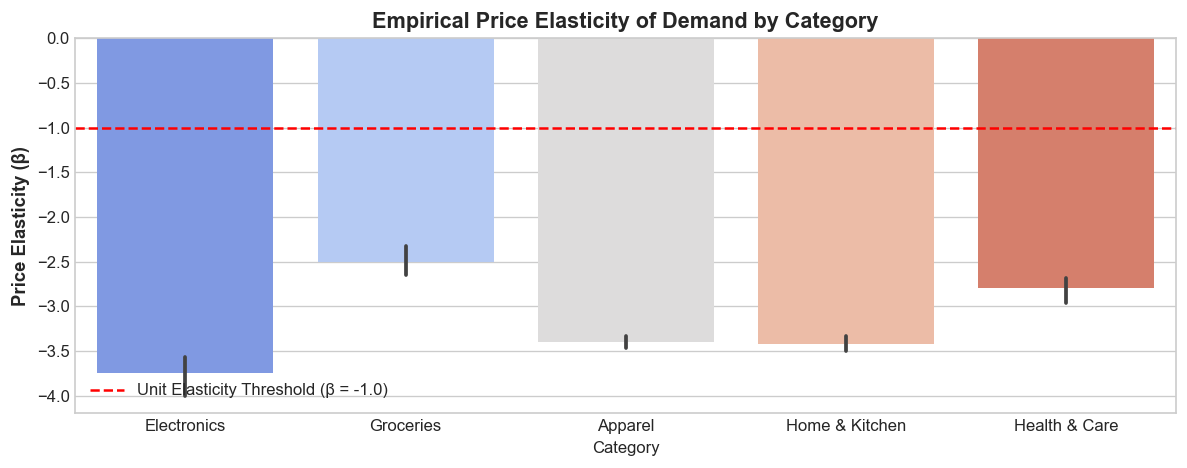

In [4]:
# Visualize Elasticity by Category
plt.figure(figsize=(10, 4))
sns.barplot(data=elasticity_df, x='Category', y='Own_Price_Elasticity', palette='coolwarm')
plt.axhline(-1.0, color='red', linestyle='--', label='Unit Elasticity Threshold (β = -1.0)')
plt.title('Empirical Price Elasticity of Demand by Category', fontsize=13, fontweight='bold')
plt.ylabel('Price Elasticity (β)', fontsize=11, fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


## 3. Dynamic Price Simulation & Optimization Curves
Simulating candidate price responses for a representative product to observe the trade-off between price, predicted demand, and expected revenue/profit.


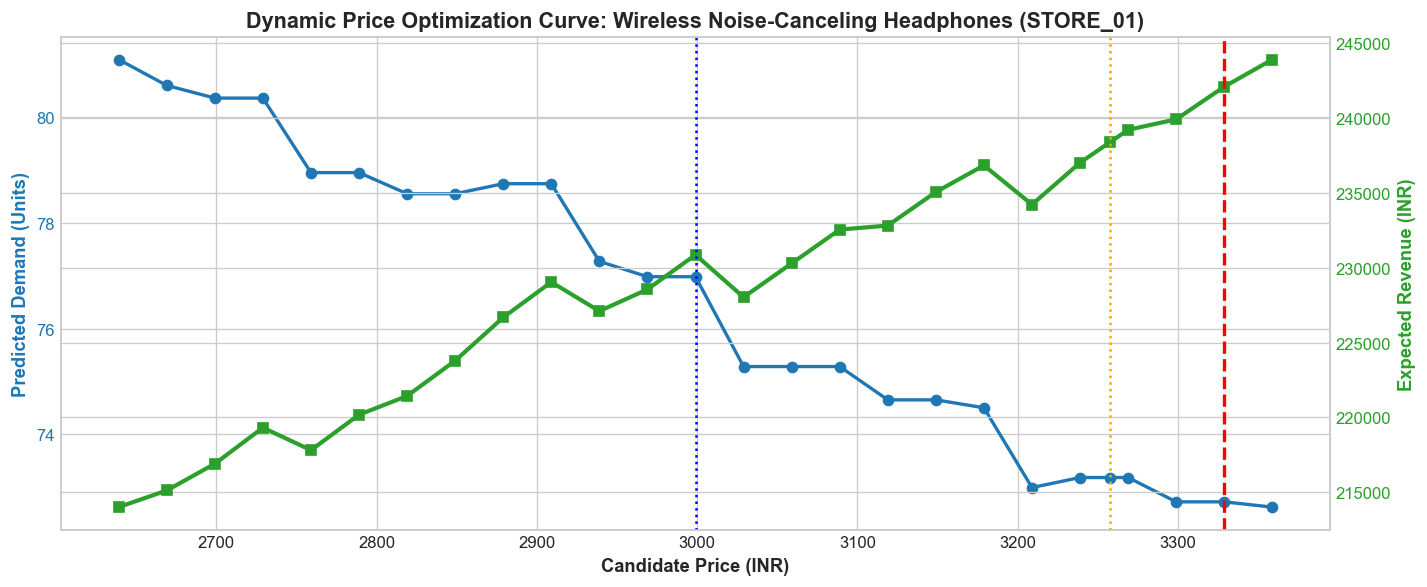

Optimization Outcome:
 - Current Price: INR 2999.00 | Current Exp. Revenue: INR 230,863.60
 - Recommended Price: INR 3328.89 | Recommended Exp. Revenue: INR 242,091.89
 - Revenue Improvement: +4.86%
 - Confidence: MEDIUM (High historical observation density (>100); Candidate price requires extrapolation outside observed envelope; Demand model demonstrated high validation explanatory power (R²=0.85))
 - Recommendation Reason: Price increase to INR 3328.89 captures margin while keeping competitor gap at 2.2%, yielding expected revenue lift of +4.86%.


In [5]:
# Select the latest state for PROD_01 in Store_01
sample_state = df[(df['Product_ID'] == 'PROD_01') & (df['Store_ID'] == 'STORE_01')].iloc[[-1]]
hist_p = df[(df['Product_ID'] == 'PROD_01') & (df['Store_ID'] == 'STORE_01')]['Our_Price']

rec = engine.optimize_price(sample_state, hist_prices_series=hist_p, objective="MAX_REVENUE", max_increase_pct=12.0, max_decrease_pct=12.0)

sim_curve = rec['Simulation_Grid']

fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#1f77b4'
ax1.set_xlabel('Candidate Price (INR)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted Demand (Units)', color=color, fontsize=11, fontweight='bold')
ax1.plot(sim_curve['Candidate_Price'], sim_curve['Predicted_Demand'], color=color, marker='o', linewidth=2, label='Demand Curve')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#2ca02c'
ax2.set_ylabel('Expected Revenue (INR)', color=color, fontsize=11, fontweight='bold')
ax2.plot(sim_curve['Candidate_Price'], sim_curve['Expected_Revenue'], color=color, marker='s', linewidth=2.5, label='Expected Revenue')
ax2.tick_params(axis='y', labelcolor=color)

# Markers for Current, Competitor, and Recommended
plt.axvline(rec['Current_Price'], color='blue', linestyle=':', label=f"Current Price (INR {rec['Current_Price']:.2f})")
plt.axvline(rec['Competitor_Price'], color='orange', linestyle=':', label=f"Competitor Price (INR {rec['Competitor_Price']:.2f})")
plt.axvline(rec['Recommended_Price'], color='red', linestyle='--', linewidth=2, label=f"Optimal Price (INR {rec['Recommended_Price']:.2f})")

plt.title(f"Dynamic Price Optimization Curve: {rec['Product_Name']} (STORE_01)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Optimization Outcome:")
print(f" - Current Price: INR {rec['Current_Price']:.2f} | Current Exp. Revenue: INR {rec['Current_Expected_Revenue']:,.2f}")
print(f" - Recommended Price: INR {rec['Recommended_Price']:.2f} | Recommended Exp. Revenue: INR {rec['Recommended_Expected_Revenue']:,.2f}")
print(f" - Revenue Improvement: {rec['Revenue_Improvement_Percent']:+.2f}%")
print(f" - Confidence: {rec['Confidence_Level']} ({rec['Confidence_Rationale']})")
print(f" - Recommendation Reason: {rec['Recommendation_Reason']}")


## 4. Enterprise-Wide Dynamic Pricing Recommendations
Executing the pricing optimization engine across all 20 products and 4 store locations using current operational states and pricing guardrails.


In [6]:
# Run optimization across latest active state of all (Product, Store) pairs
latest_date = df['Date'].max()
latest_df = df[df['Date'] == latest_date].copy()

all_recs = []
for _, row in latest_df.iterrows():
    row_df = pd.DataFrame([row])
    p_id = row['Product_ID']
    s_id = row['Store_ID']
    hist_series = df[(df['Product_ID'] == p_id) & (df['Store_ID'] == s_id)]['Our_Price']
    
    r = engine.optimize_price(
        row_df,
        hist_prices_series=hist_series,
        objective="MAX_REVENUE",
        max_increase_pct=10.0,
        max_decrease_pct=10.0,
        max_competitor_premium_pct=5.0
    )
    # Exclude simulation grid for CSV export
    r_dict = {k: v for k, v in r.items() if k != "Simulation_Grid"}
    all_recs.append(r_dict)

recs_df = pd.DataFrame(all_recs)
recs_df.to_csv("outputs/pricing_recommendations.csv", index=False)

print(f"Generated {len(recs_df)} Dynamic Pricing Recommendations.")
print(tabulate(
    recs_df[['Product_ID', 'Store_ID', 'Current_Price', 'Competitor_Price', 'Recommended_Price', 'Price_Change_Percent', 'Revenue_Improvement_Percent', 'Confidence_Level']].head(10),
    headers=["Product", "Store", "Cur Price", "Comp Price", "Rec Price", "Price Δ %", "Rev Lift %", "Confidence"],
    tablefmt="psql",
    floatfmt=(".2f", ".2f", ".2f", ".2f", ".2f", "+.2f", "+.2f", "")
))


Generated 80 Dynamic Pricing Recommendations.
+----+-----------+----------+-------------+--------------+-------------+-------------+--------------+--------------+
|    | Product   | Store    |   Cur Price |   Comp Price |   Rec Price |   Price Δ % |   Rev Lift % | Confidence   |
|----+-----------+----------+-------------+--------------+-------------+-------------+--------------+--------------|
|  0 | PROD_01   | STORE_01 |     2999.00 |      3257.52 |    +3268.91 |       +9.00 |         3.62 | MEDIUM       |
|  1 | PROD_01   | STORE_02 |     2999.00 |      2950.15 |    +3088.97 |       +3.00 |         1.17 | HIGH         |
|  2 | PROD_01   | STORE_03 |     2999.00 |      3192.84 |    +3268.91 |       +9.00 |         6.03 | MEDIUM       |
|  3 | PROD_01   | STORE_04 |     2699.10 |      3211.16 |    +2942.02 |       +9.00 |         7.89 | HIGH         |
|  4 | PROD_02   | STORE_01 |     4274.05 |      4515.92 |    +4701.45 |      +10.00 |         9.78 | HIGH         |
|  5 | PROD_02   |

## 5. What-If Pricing Simulator Function
Interactive simulation tool enabling commercial managers to test hypothetical price changes and observe predicted demand, revenue, competitor gaps, and guardrail statuses.


In [7]:
def run_what_if_analysis(product_id, store_id, proposed_price):
    """
    Interactive simulation helper for commercial decision makers.
    """
    state = df[(df['Product_ID'] == product_id) & (df['Store_ID'] == store_id)].iloc[[-1]]
    cur_p = float(state['Our_Price'].iloc[0])
    comp_p = float(state['Competitor_Price'].iloc[0])
    
    sim_result = engine.simulate_price_change(state, proposed_price)
    cur_result = engine.simulate_price_change(state, cur_p)
    
    rev_change = ((sim_result['Expected_Revenue'] - cur_result['Expected_Revenue']) / cur_result['Expected_Revenue']) * 100.0
    demand_change = ((sim_result['Predicted_Demand'] - cur_result['Predicted_Demand']) / cur_result['Predicted_Demand']) * 100.0
    
    table_data = [
        ["Current State", f"INR {cur_p:.2f}", f"{cur_result['Predicted_Demand']:.1f}", f"INR {cur_result['Expected_Revenue']:,.2f}", "Baseline"],
        ["Simulated State", f"INR {proposed_price:.2f}", f"{sim_result['Predicted_Demand']:.1f}", f"INR {sim_result['Expected_Revenue']:,.2f}", sim_result['Guardrail_Status']],
        ["Impact / Delta", f"{((proposed_price - cur_p)/cur_p)*100:+.2f}%", f"{demand_change:+.2f}%", f"{rev_change:+.2f}%", "—"]
    ]
    
    print(f"=== WHAT-IF SIMULATION: {state['Product_Name'].iloc[0]} ({store_id}) ===")
    print(f"Competitor Price: INR {comp_p:.2f} | Gap: {sim_result['Competitor_Gap_Percent']:+.2f}%")
    print(tabulate(table_data, headers=["Scenario", "Price", "Predicted Demand", "Expected Revenue", "Guardrail Status"], tablefmt="fancy_grid"))

# Test What-If scenarios
run_what_if_analysis("PROD_01", "STORE_01", 2850.0)
run_what_if_analysis("PROD_01", "STORE_01", 3100.0)


=== WHAT-IF SIMULATION: Wireless Noise-Canceling Headphones (STORE_01) ===
Competitor Price: INR 3257.52 | Gap: -12.51%
╒═════════════════╤═════════════╤════════════════════╤════════════════════╤════════════════════╕
│ Scenario        │ Price       │ Predicted Demand   │ Expected Revenue   │ Guardrail Status   │
╞═════════════════╪═════════════╪════════════════════╪════════════════════╪════════════════════╡
│ Current State   │ INR 2999.00 │ 77.0               │ INR 230,863.60     │ Baseline           │
├─────────────────┼─────────────┼────────────────────┼────────────────────┼────────────────────┤
│ Simulated State │ INR 2850.00 │ 78.5               │ INR 223,864.90     │ PASSED             │
├─────────────────┼─────────────┼────────────────────┼────────────────────┼────────────────────┤
│ Impact / Delta  │ -4.97%      │ +2.04%             │ -3.03%             │ —                  │
╘═════════════════╧═════════════╧════════════════════╧════════════════════╧════════════════════╛
=== WHA